# House Price Prediction using Machine Learning

## Import Libraries 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
data = pd.read_csv(r"C:\Users\Shruti\Downloads\House price prediction\train.csv")
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
df = pd.DataFrame(data)

## Dataset Overview

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [6]:
df.shape

(1460, 81)

In [7]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [10]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

## Check Missing Values

In [11]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

### check missing values in percentage

In [12]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing = missing[missing["Missing Values"] > 0]
missing = missing.sort_values(by="Percentage", ascending=False)

missing

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


## Duplicated Rows

In [13]:
duplicate_count = df.duplicated().sum()
print(duplicate_count)

0


## Data Cleaning 

In [14]:
# Drop the columns with more then 50% missing values

drop_columns = [
    'PoolQC',
    'MiscFeature',
    'Alley',
    'Fence',
    'MasVnrType'
]

df.drop(columns=drop_columns, inplace=True, errors='ignore')

print("Columns drop successfully")

Columns drop successfully


In [15]:
# Fill numarical values with median

num_cols = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Numarical missing values filled")

Numarical missing values filled


In [16]:
# Fill categorical values with mode

cat_cols = [
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'BsmtFinType2',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtCond',
    'BsmtQual',
    'Electrical'
]

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Categorical missing values filled")

Categorical missing values filled


In [17]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


## Exploratory Data Analysis(EDA)

In [18]:
# Target variable

df["SalePrice"].head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

### Boxplot of saleprice


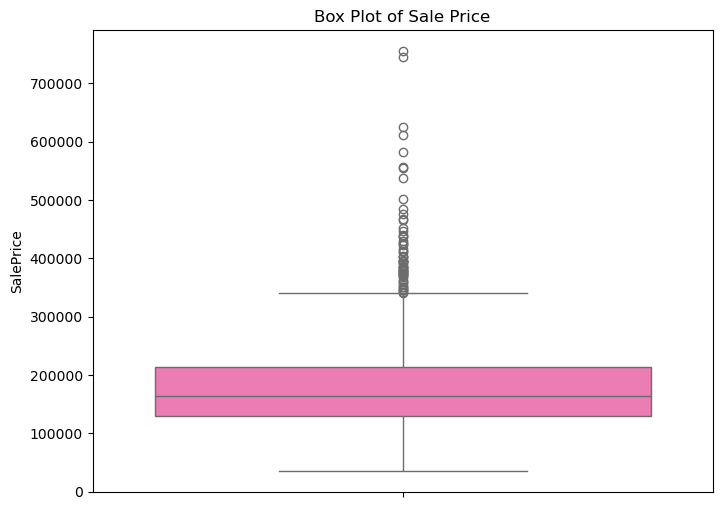

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(y = df['SalePrice'], color='hotpink')
plt.title("Box Plot of Sale Price")
plt.show()

### Distribution of SalePrice

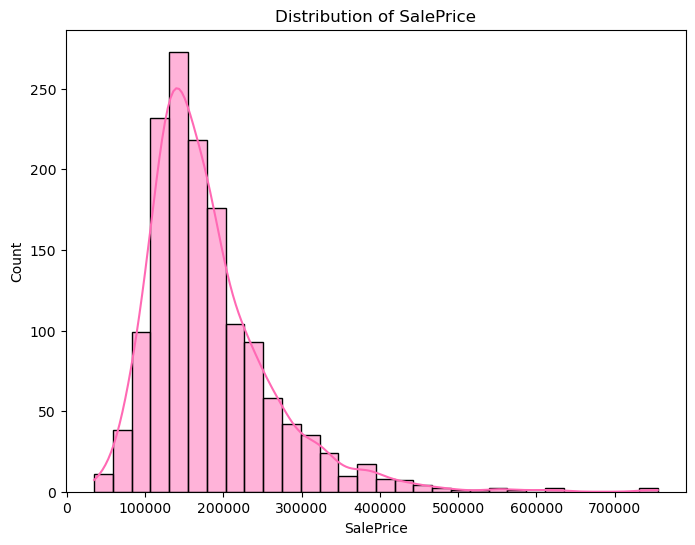

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(df['SalePrice'], bins=30, kde=True, color = 'hotpink')
plt.title("Distribution of SalePrice")
plt.show()

### Correlation Heatmap

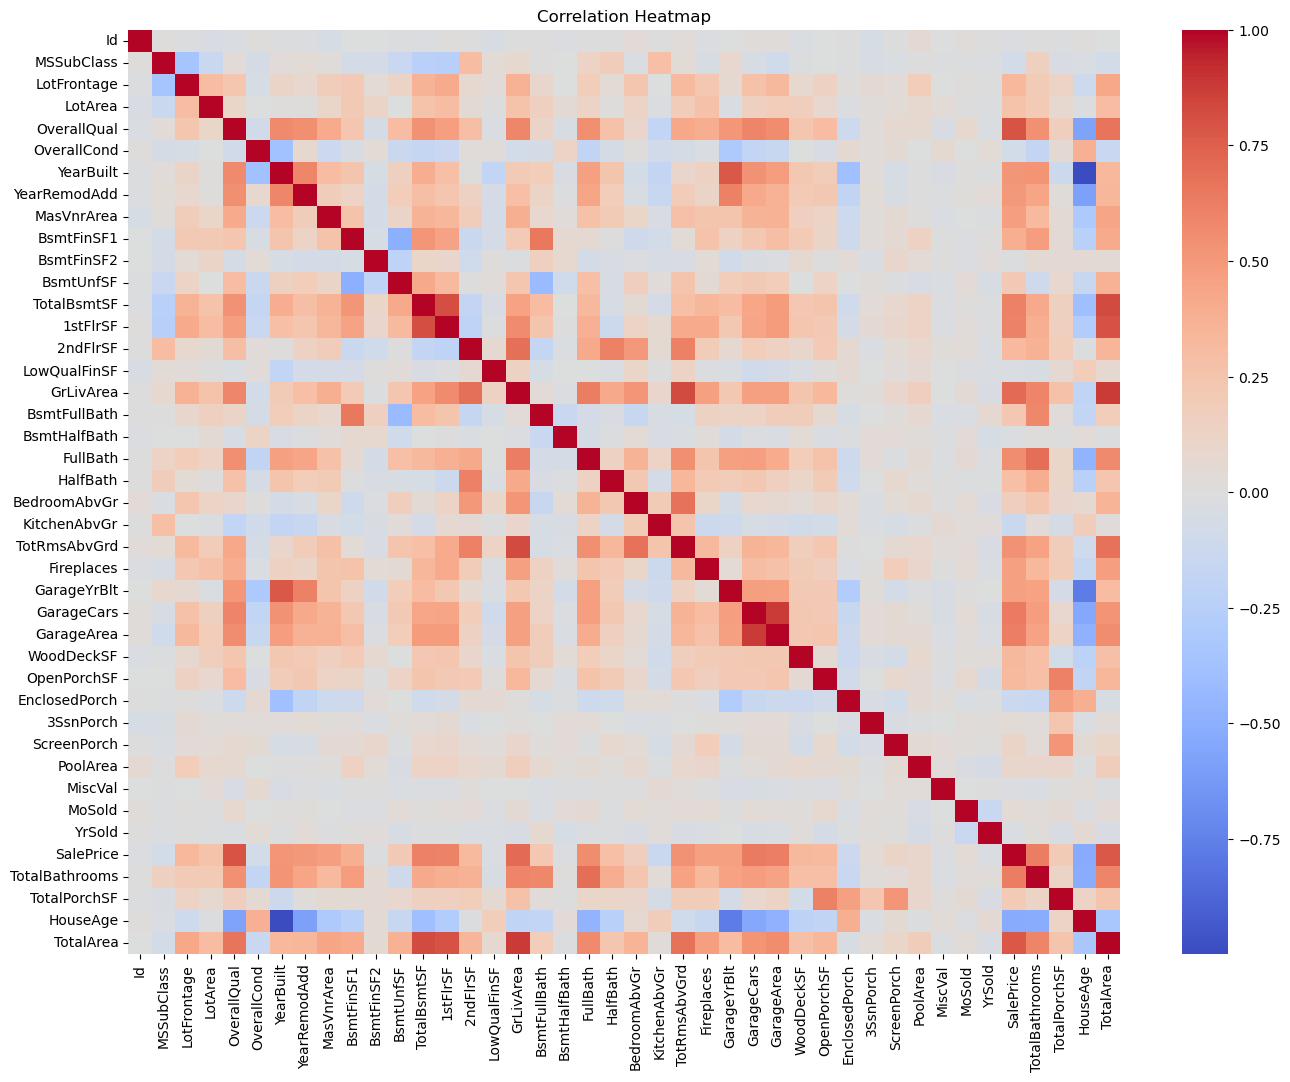

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,12))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Scatter plot

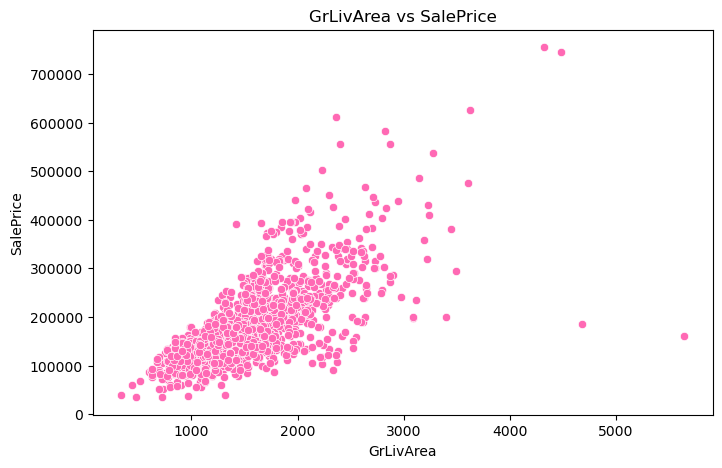

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x = 'GrLivArea', y = 'SalePrice', data = df, color = 'hotpink')
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

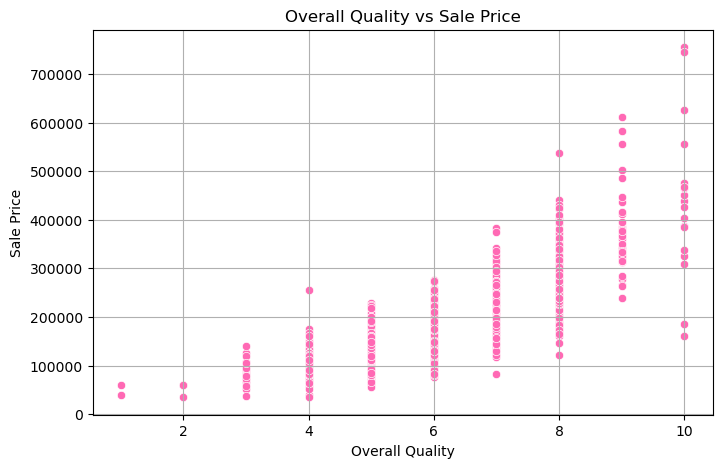

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x = 'OverallQual', y = 'SalePrice', data = df, color = 'hotpink')
plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.grid(True)
plt.show()

### Count plot

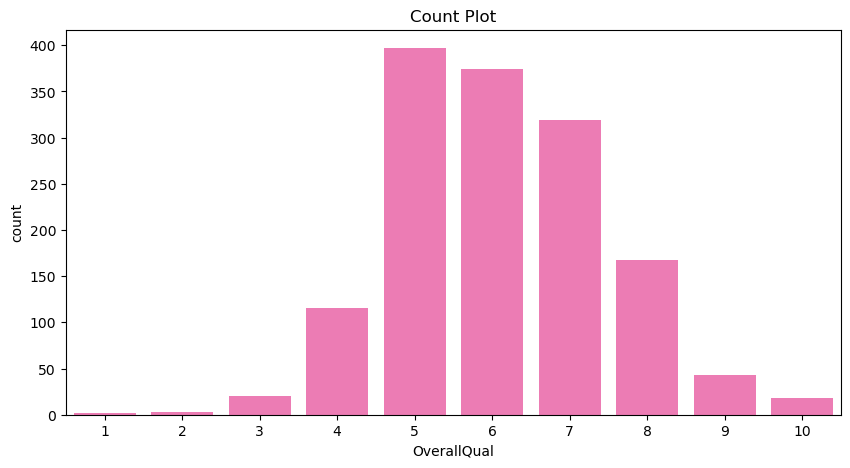

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(x='OverallQual',data=df, color = 'hotpink')
plt.title("Count Plot")
plt.show()

### Histogram of Numerical Feature


Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'TotalBathrooms',
       'TotalPorchSF', 'HouseAge', 'TotalArea'],
      dtype='object')


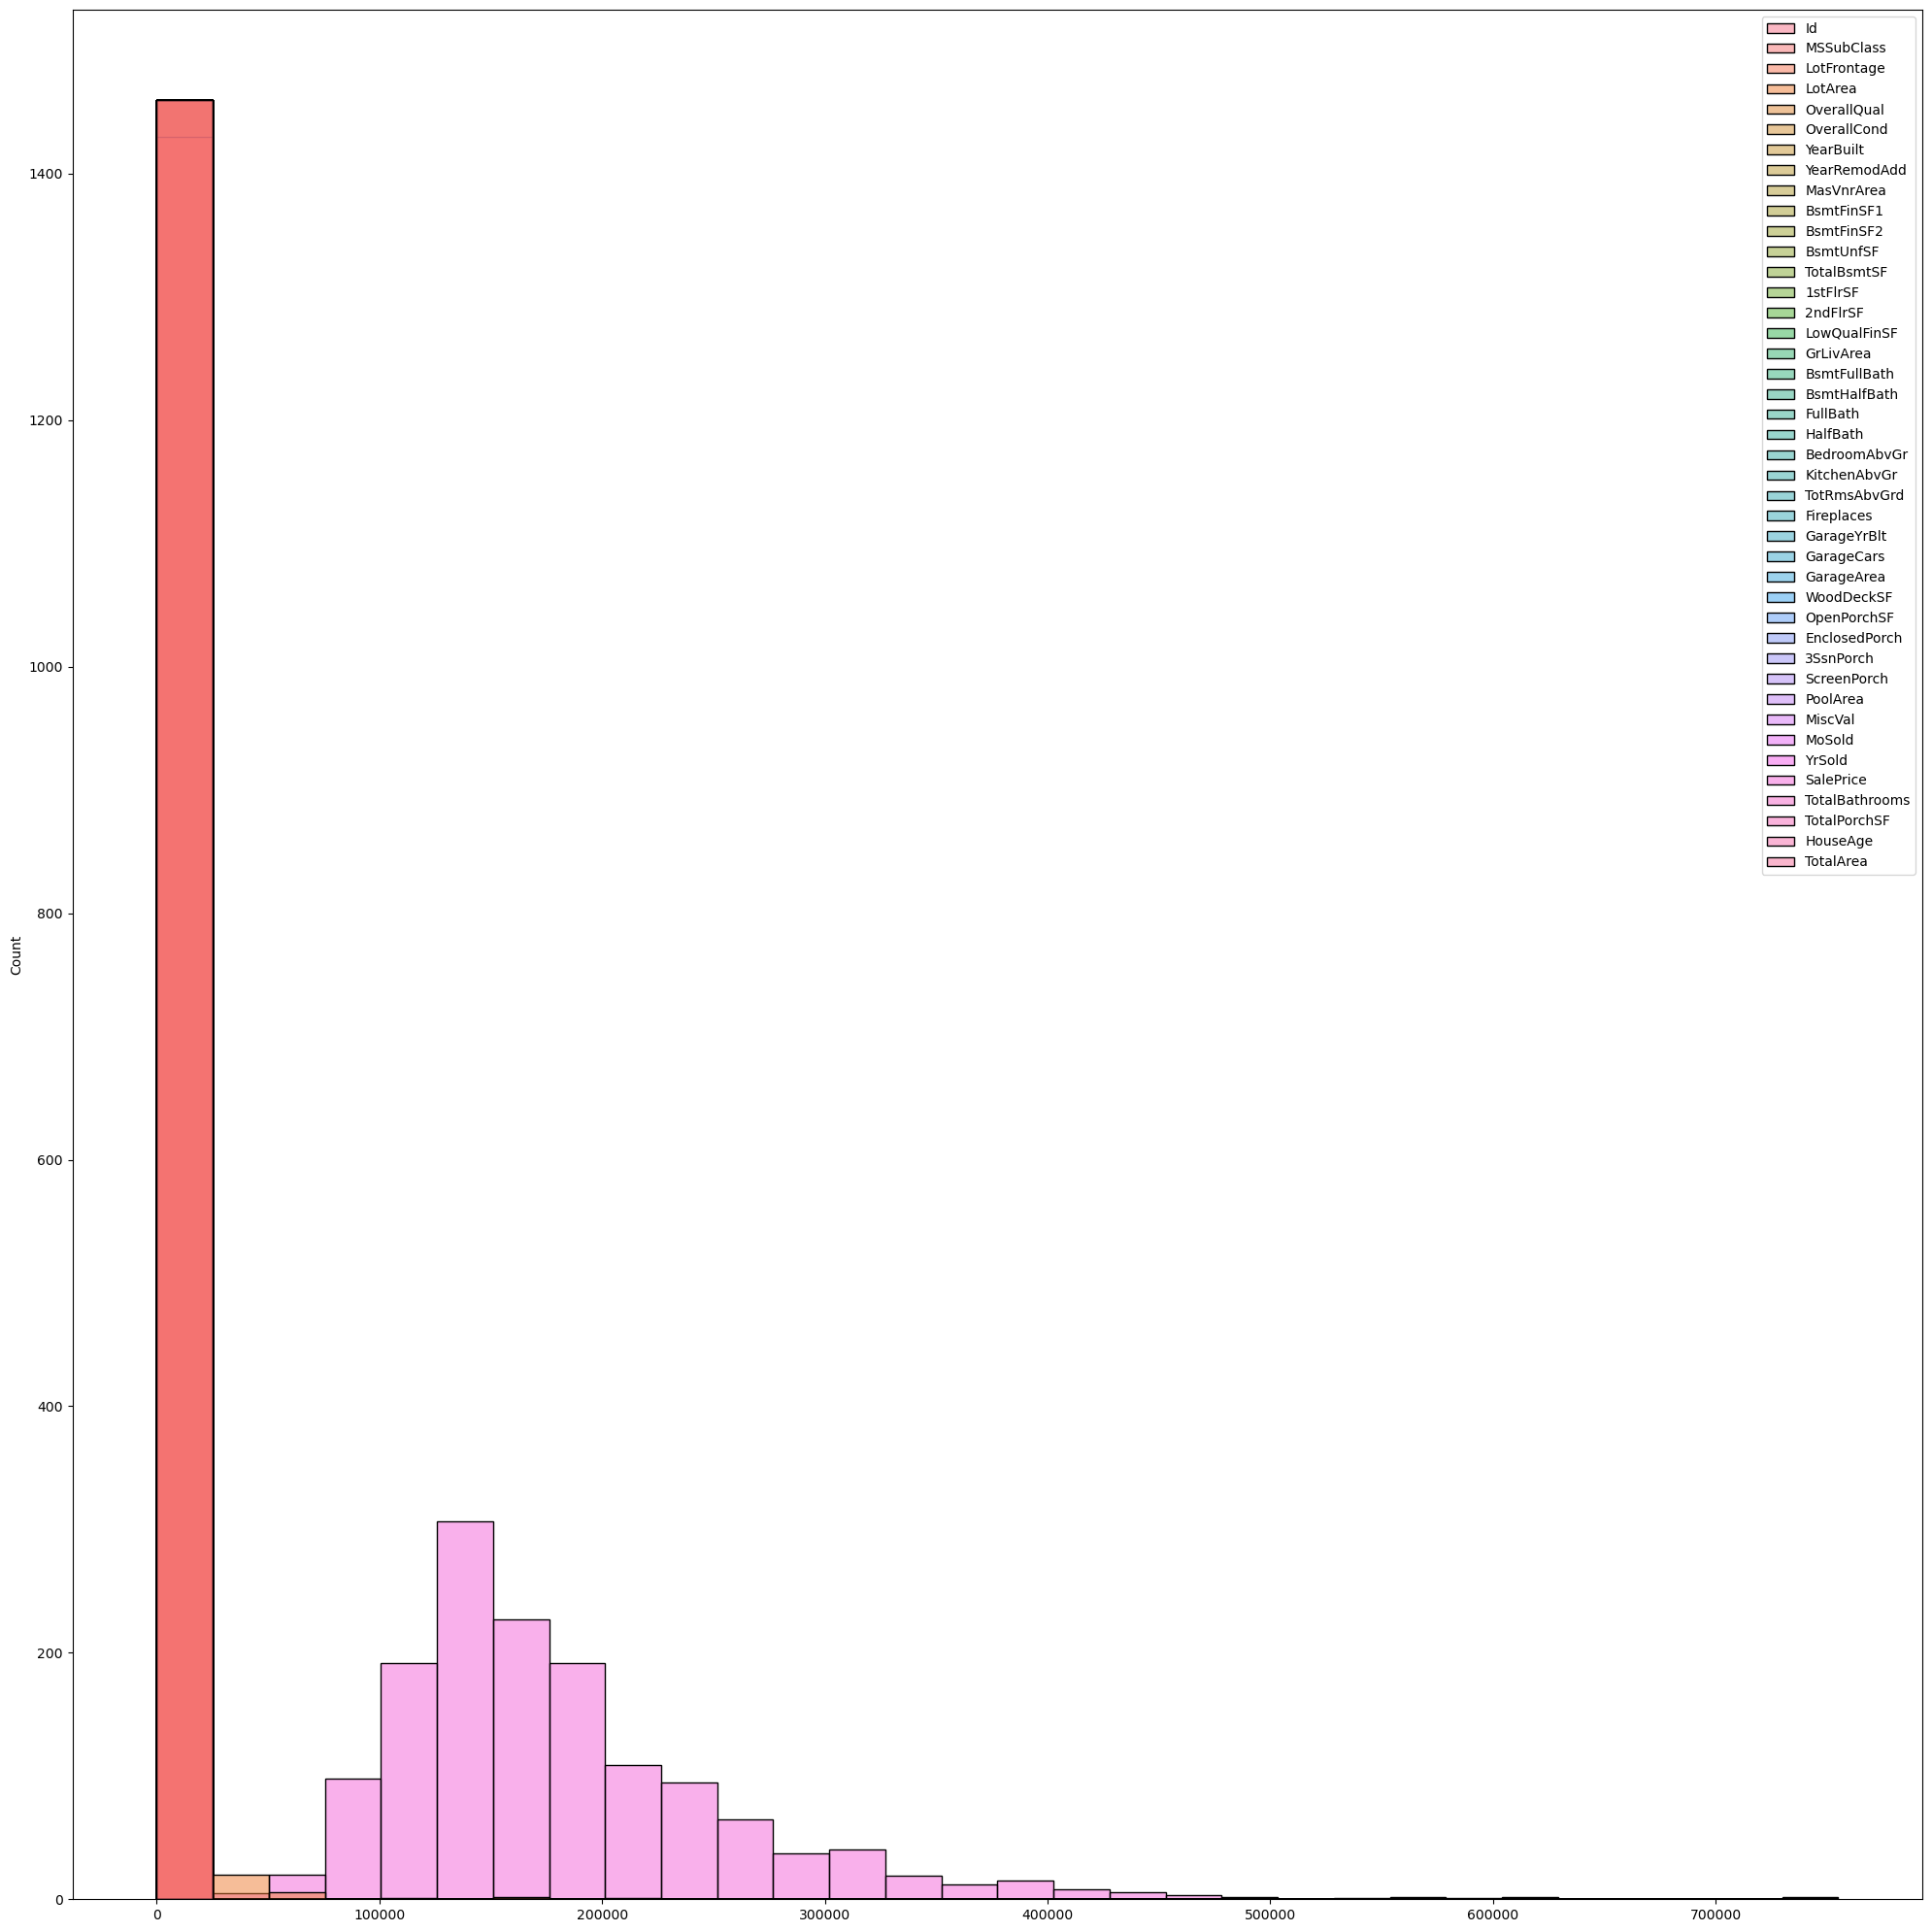

In [65]:
import matplotlib.pyplot as plt

# Frist find all numerical columns
num_cols = df.select_dtypes(include = ['int64', 'float64']).columns
print(num_cols)

# Now draw histogram

plt.show()
plt.figure(figsize=(20,20))
sns.histplot(df[num_cols], bins=30)
plt.tight_layout()
plt.show()

### Pair Plot


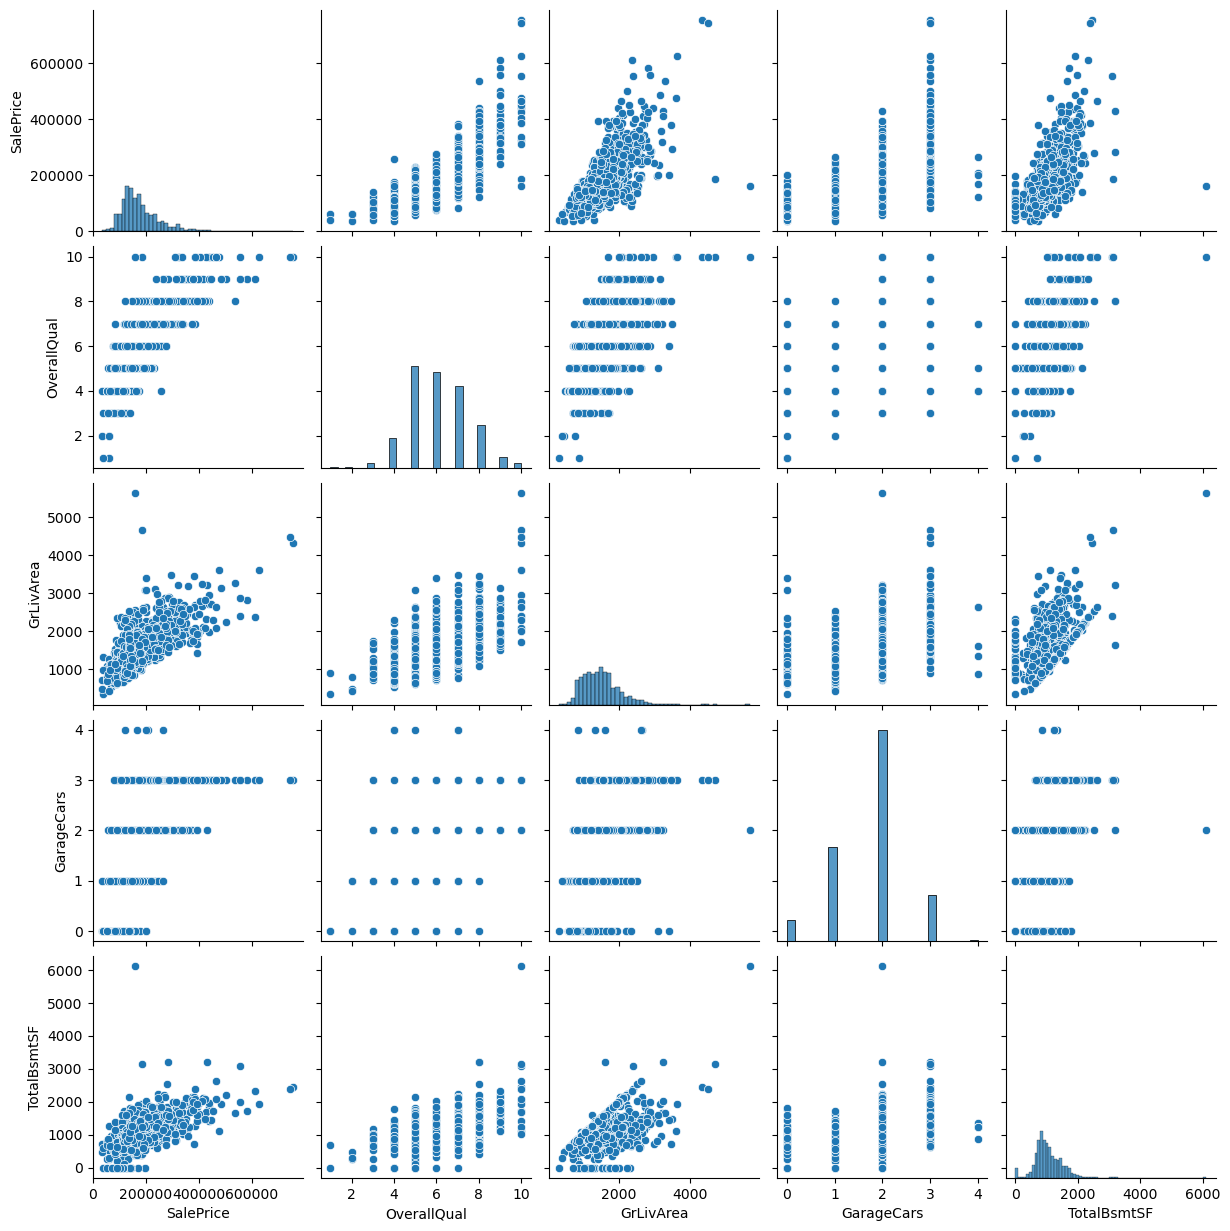

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_features = [
    'SalePrice',
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF'
]
sns.pairplot(df[selected_features])
plt.show()

## Feature Engineering


In [58]:
# create some new useful feature

# Total Bathrooms :

df['TotalBathrooms'] = (
      df['FullBath']
    + 0.5 * df['HalfBath']
    + df['BsmtFullBath']
    + 0.5 * df['BsmtHalfBath']
)



# Total Porch Area :

df['TotalPorchSF'] = (
      df['OpenPorchSF']
    + df['EnclosedPorch']
    + df['3SsnPorch']
    + df['ScreenPorch']
)



# House Age :

df['HouseAge'] = df['YrSold'] - df['YearBuilt']



# Total Area :

df['TotalArea'] = (
      df['GrLivArea']
    + df['TotalBsmtSF']
)



# Cheak the new columns : 

df[['TotalBathrooms','TotalPorchSF','HouseAge','TotalArea']].head()

,TotalBathrooms,TotalPorchSF,HouseAge,TotalArea
0,3.5,61,5,2566
1,2.5,0,31,2524
2,3.5,42,7,2706
3,2.0,307,91,2473
4,3.5,84,8,3343


## Encoding 

In [67]:
X = df.drop('SalePrice' , axis =  1 )
y = df['SalePrice']

In [72]:
# Convert categorical variables into numeric values.
X = pd.get_dummies(X, drop_first=True)

# Check shape 
X.shape

(1460, 238)

## Train-Test Split

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.20, random_state = 42)

print(X_train.shape)
print(X_test.shape)

(1168, 238)
(292, 238)


## Model 1: Linear Regression

In [94]:
from sklearn.linear_model import LinearRegression
# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)


LinearRegression()

In [90]:
# Prediction
lr_pred = lr.predict(X_test)
lr_pred

array([ 155687.65265228,  353150.57684536,   89783.41202168,
        175246.85303358,  318712.96543422,   65813.39939341,
        232906.07493687,  147642.34025465,   57065.21416311,
        147347.81398785,  144587.95088678,  102456.84230543,
         80264.67173639,  220623.84534264,  175487.89883886,
        131174.04410903,  187321.9613953 ,  133981.15641911,
        130007.52650825,  216646.02473887,  160809.15265739,
        206055.9108045 ,  168657.46208236,  128002.65087195,
        198925.09249931,  133852.89722483,  193920.21789573,
        104054.31871601,  176747.95299725,  203346.93771325,
        162530.61323567,  277475.30802759,  249957.60118418,
        111303.08081237,  235408.9507918 ,  150870.06111053,
        139922.8944927 ,  200391.72945839,  310412.15584817,
        103949.29009961,  121215.43577503,  217280.21253788,
        100313.61737381,  373260.63681557,  131502.93722262,
        142031.11052434,   96770.91352366,  137731.2383953 ,
        418638.93462286,

## Evaluate Linear Regression

In [108]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_mse = mean_squared_error(y_test, lr_pred)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_pred)

print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE :", lr_rmse)
print("R2 Score :", lr_r2)

MAE : 20466.390350558842
MSE : 2740456435.634132
RMSE : 52349.369008939655
R2 Score : 0.6427197016645376


## Actual vs Predicted

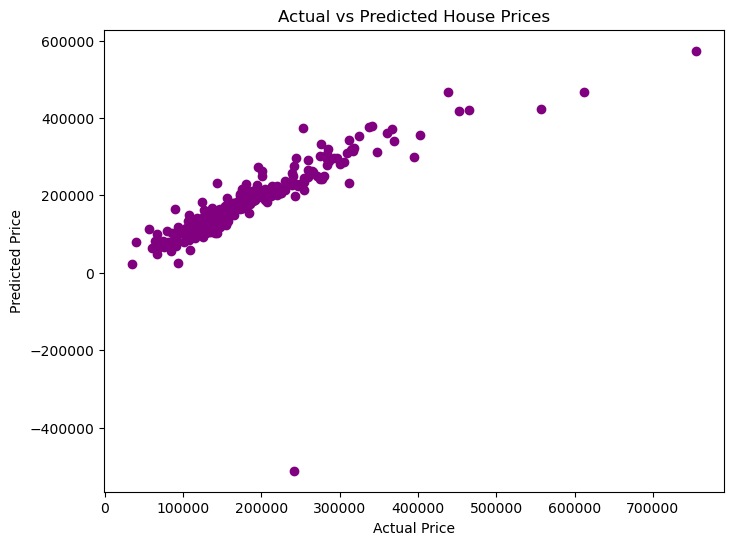

In [99]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_pred, color='purple')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## Model 2: Decision Tree Regressor

In [91]:
from sklearn.tree import DecisionTreeRegressor

# Create model
dt_model = DecisionTreeRegressor(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [93]:
# Prediction
dt_pred = dt_model.predict(X_test)
dt_pred

array([139400., 381000., 105500., 210000., 392000.,  81000., 175500.,
       148500.,  80000., 139500., 103600., 135000., 116050., 191000.,
       175000., 109000., 185000., 119200., 120000., 226000., 190000.,
       178000., 179665., 120000., 215000., 179200., 200141.,  82500.,
       179000., 179600., 130000., 219500., 190000.,  82500., 250000.,
       139400., 160000., 165400., 299800., 109900., 105500., 235000.,
       115000., 378500., 157000., 125000., 115000., 144000., 426000.,
       141500., 112500., 205000.,  52000., 430000., 131500., 225000.,
       185000., 149900., 139000., 122900.,  60000., 136905., 325300.,
       225000., 239000., 237500., 116000., 361919.,  88000., 177000.,
       118964., 132000., 128000.,  92900., 501837., 179200., 340000.,
       320000., 139000., 129500., 110500., 108000., 100000.,  52000.,
       159500., 124900., 244600., 207500., 131500., 173900.,  87000.,
       145000., 130500., 315750., 142600., 176432., 195000., 154000.,
       189000., 2380

## Evaluate Decision Tree

In [96]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

dt_mae = mean_absolute_error(y_test, dt_pred)

dt_mse = mean_squared_error(y_test, dt_pred)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE :", dt_rmse)
print("R2 Score :", dt_r2)

Decision Tree Results
MAE : 27946.90068493151
MSE : 1954736171.0993152
RMSE : 44212.39838664394
R2 Score : 0.7451560574740981


## Actual vs Predicted

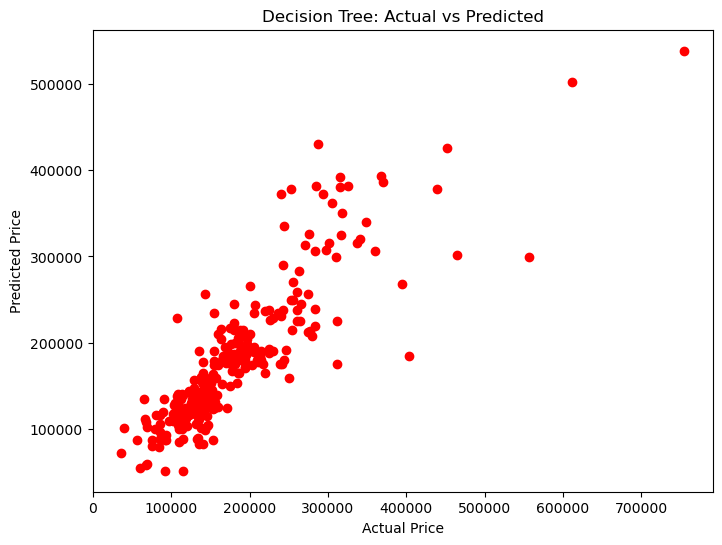

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, dt_pred, color="red")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

## Model 3: Random Forest Regressor

In [101]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [103]:
# Prediction
rf_pred = rf_model.predict(X_test)
rf_pred

array([140653.75, 336167.12, 112593.04, 157797.  , 314349.43,  83839.  ,
       197910.3 , 153933.52,  87138.  , 131110.27, 144587.34, 124618.5 ,
       112549.  , 213100.34, 179658.32, 129986.5 , 195675.29, 132726.09,
       113739.04, 210863.05, 171443.  , 206316.04, 178174.02, 123027.25,
       201289.53, 177039.58, 188216.38, 104070.  , 178819.35, 198473.47,
       122224.34, 244003.74, 216132.09, 113504.5 , 259333.81, 146252.5 ,
       147522.75, 207550.54, 324173.74, 102757.83, 116457.  , 230706.16,
       116874.49, 397873.92, 134371.1 , 146294.57, 117898.16, 127130.  ,
       397180.8 , 141235.96, 123961.5 , 193594.7 , 105900.5 , 338898.77,
       140909.  , 237382.59, 194959.  , 152460.53, 146500.5 , 111212.47,
        73220.5 , 152831.65, 300290.47, 255799.7 , 291243.74, 215040.77,
       116253.58, 324531.71, 114786.  , 167499.24, 119254.11, 129606.83,
       115098.  ,  89053.64, 461787.3 , 186152.53, 327982.66, 297172.75,
       135085.42, 115079.5 ,  98688.28, 105657.91, 

## Evaluate Random Forest

In [104]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

Random Forest Results
MAE : 18252.835547945208
MSE : 906277215.6540384
RMSE : 30104.438470996905
R2 Score : 0.8818463268478917


## Actual vs Predicted

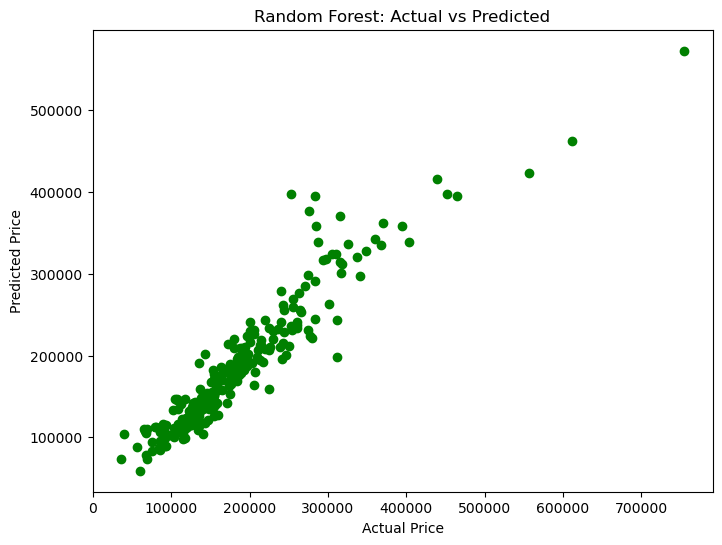

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred, color="green")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

## Compare All Models

In [109]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],

    "R2 Score":[
        lr_r2,
        dt_r2,
        rf_r2
    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,20466.390351,52349.369009,0.642720
1,Decision Tree,27946.900685,44212.398387,0.745156
2,Random Forest,18252.835548,30104.438471,0.881846


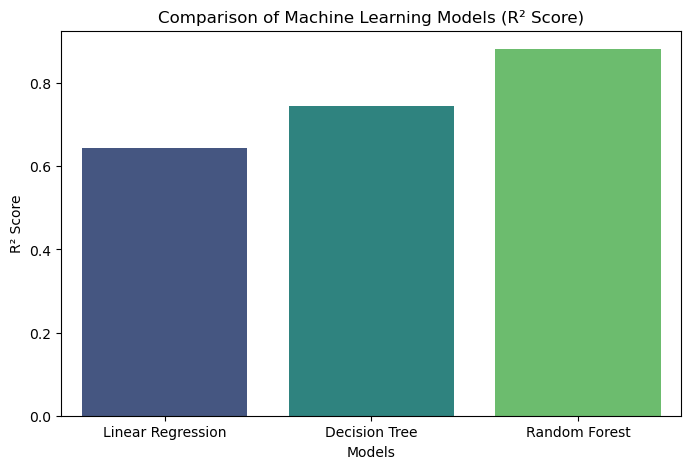

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2 Score', data=comparison, palette='viridis')
plt.title("Comparison of Machine Learning Models (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.show()

## Sort Models by R² Score

In [110]:
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,18252.835548,30104.438471,0.881846
1,Decision Tree,27946.900685,44212.398387,0.745156
0,Linear Regression,20466.390351,52349.369009,0.642720


## Feature Importance - Random Forest

In [112]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(by="Importance", ascending=False)
importance.head(15)

,Feature,Importance
4,OverallQual,0.402731
40,TotalArea,0.345473
14,2ndFlrSF,0.027346
6,YearBuilt,0.016375
9,BsmtFinSF1,0.012956
3,LotArea,0.012208
7,YearRemodAdd,0.011451
37,TotalBathrooms,0.010869
39,HouseAge,0.010849
2,LotFrontage,0.010435


## Plot Feature Importance

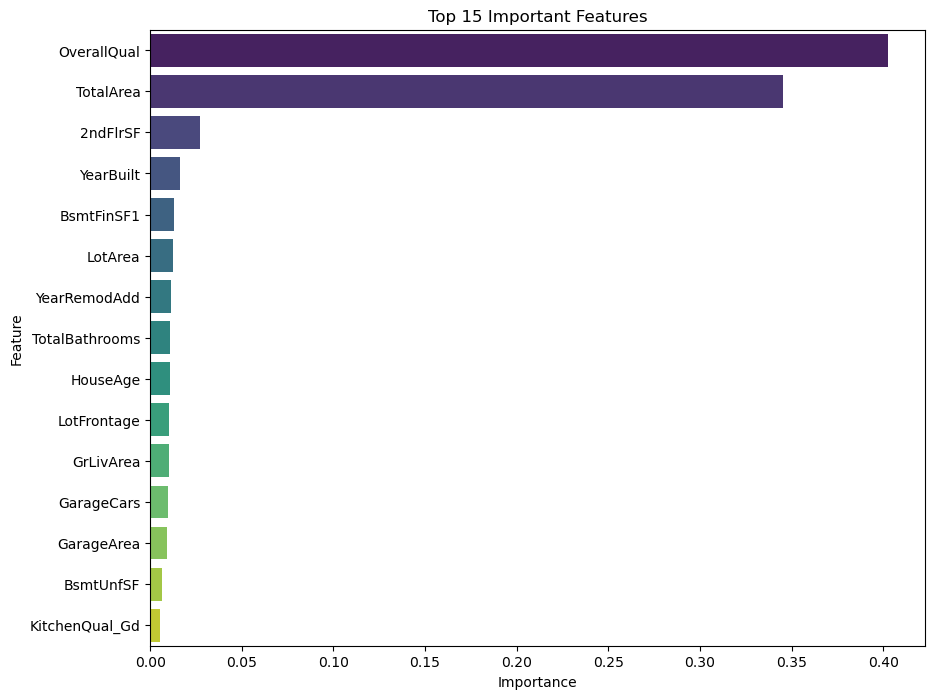

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.barplot(data=importance.head(15),x="Importance", y="Feature", palette="viridis")
plt.title("Top 15 Important Features")
plt.show()

## Conclusions

#### This project successfully developed a machine learning model to predict house prices using the House Prices dataset. The project followed a complete machine learning workflow, including data understanding, data cleaning, exploratory data analysis (EDA), feature engineering, data preprocessing, model training, and performance evaluation.

#### Three regression algorithms were implemented and compared: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

#### The Random Forest Regressor achieved the best overall performance with an MAE of 18,252.84, an RMSE of 30,104.44, and an R² Score of 0.8818, indicating that it explained approximately 88.18% of the variation in house prices. In comparison, the Decision Tree Regressor achieved an R² Score of 0.7452, while Linear Regression achieved an R² Score of 0.6427.

#### Based on these evaluation results, the Random Forest Regressor was selected as the best-performing model because it provided the highest prediction accuracy and the lowest prediction error among the evaluated algorithms.

#### Overall, this project demonstrates the practical application of machine learning techniques for solving real-world regression problems. It also highlights the importance of data preprocessing, feature engineering, and model comparison in building accurate predictive models. The skills and techniques used in this project can be applied to similar predictive analytics problems in domains such as real estate, finance, and business intelligence.